# 03/ Statistical Analysis

This notebook tests whether product category co-purchases are statistically
significant, and whether those associations vary by time slot.

**Statistical methods:**
- Chi-squared test (H₀: categories A and B are purchased independently)
- Cramér's V (strength of association)
- Odds Ratio (magnitude of commercial effect)

**Significance threshold:** α = 0.05

In [27]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path

# Load category pairs dataset
pairs_df = pd.read_csv(Path("../data/category_pairs.csv"))

print(f"Total category pairs: {len(pairs_df)}")
print(f"Unique pairs: {pairs_df[['category_a', 'category_b']].drop_duplicates().shape[0]}")
print(f"Time slots: {pairs_df['time_slot'].unique()}")
pairs_df.head()

Total category pairs: 27283
Unique pairs: 15
Time slots: <StringArray>
['Morning', 'Afternoon', 'Evening']
Length: 3, dtype: str


,transaction_id,date,day_of_week,time_slot,city,customer_type,category_a,category_b
0,TXN-09301,2024-01-01,Monday,Morning,Quito,New,Dairy products and eggs,Fruits and vegetables
1,TXN-09301,2024-01-01,Monday,Morning,Quito,New,Dairy products and eggs,Meats and sausages
2,TXN-09301,2024-01-01,Monday,Morning,Quito,New,Dairy products and eggs,Snacks and drinks
3,TXN-09301,2024-01-01,Monday,Morning,Quito,New,Fruits and vegetables,Meats and sausages
4,TXN-09301,2024-01-01,Monday,Morning,Quito,New,Fruits and vegetables,Snacks and drinks


## Statistical functions

In [28]:
def cramers_v(contingency_table):
    """Calculate Cramér's V from a contingency table."""
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    v = np.sqrt(chi2 / (n * min_dim))
    return chi2, p, dof, v

def odds_ratio(a, b, c, d):
    """
    Calculate Odds Ratio from a 2x2 table:
    a = both present, b = only A, c = only B, d = neither
    """
    if b * c == 0:
        return np.nan
    return (a * d) / (b * c)

print("Functions defined successfully")

Functions defined successfully


## Global association analysis

Testing all category pairs across the full dataset.

In [29]:
results = []

unique_pairs = pairs_df[["category_a", "category_b"]].drop_duplicates().values

for cat_a, cat_b in unique_pairs:

    # Transactions that contain this pair
    both = pairs_df[
        (pairs_df["category_a"] == cat_a) & 
        (pairs_df["category_b"] == cat_b)
    ]["transaction_id"].nunique()

    # Transactions with cat_a but not cat_b
    txn_with_a = set(pairs_df[
        (pairs_df["category_a"] == cat_a) | (pairs_df["category_b"] == cat_a)
    ]["transaction_id"])
    
    txn_with_b = set(pairs_df[
        (pairs_df["category_a"] == cat_b) | (pairs_df["category_b"] == cat_b)
    ]["transaction_id"])

    txn_both = txn_with_a & txn_with_b
    only_a = len(txn_with_a - txn_with_b)
    only_b = len(txn_with_b - txn_with_a)
    both = len(txn_both)
    
    all_txn = set(pairs_df["transaction_id"])
    neither = len(all_txn - txn_with_a - txn_with_b)

    ct = pd.DataFrame(
        [[neither, only_b], [only_a, both]],
        index=["A absent", "A present"],
        columns=["B absent", "B present"]
    )

    chi2, p, dof, v = cramers_v(ct)
    or_val = odds_ratio(both, only_a, only_b, neither)

    results.append({
        "Category A": cat_a,
        "Category B": cat_b,
        "Chi2": round(chi2, 4),
        "p-value": round(p, 4),
        "Significant": p < 0.05,
        "Cramér's V": round(v, 4),
        "Odds Ratio": round(or_val, 4)
    })

results_df = pd.DataFrame(results)
results_df.to_csv("../outputs/tables/global_association_results.csv", index=False)

print(f"Total pairs tested: {len(results_df)}")
print(f"Significant pairs: {results_df['Significant'].sum()}")
results_df.sort_values("Cramér's V", ascending=False)

Total pairs tested: 15
Significant pairs: 15


,Category A,Category B,Chi2,p-value,Significant,Cramér's V,Odds Ratio
2,Dairy products and eggs,Snacks and drinks,370.0990,0.0000,True,0.1924,0.4578
4,Fruits and vegetables,Snacks and drinks,290.5616,0.0000,True,0.1705,0.5017
14,Dairy products and eggs,Personal care,276.7630,0.0000,True,0.1664,0.4851
8,Fruits and vegetables,Home cleaning,237.5312,0.0000,True,0.1541,0.5334
6,Dairy products and eggs,Home cleaning,229.6999,0.0000,True,0.1516,0.5381
9,Fruits and vegetables,Personal care,187.5590,0.0000,True,0.1370,0.5552
5,Meats and sausages,Snacks and drinks,172.1349,0.0000,True,0.1312,0.5891
13,Meats and sausages,Personal care,161.5256,0.0000,True,0.1271,0.5797
12,Home cleaning,Meats and sausages,157.7215,0.0000,True,0.1256,0.6000
1,Dairy products and eggs,Meats and sausages,116.6853,0.0000,True,0.1080,0.6472


## Association analysis by time slot

Testing whether associations change across Morning, Afternoon and Evening.
This is the core differentiator of this project.

In [30]:
time_results = []

for slot in ["Morning", "Afternoon", "Evening"]:
    slot_data = pairs_df[pairs_df["time_slot"] == slot]
    unique_pairs = slot_data[["category_a", "category_b"]].drop_duplicates().values

    for cat_a, cat_b in unique_pairs:

        txn_with_a = set(slot_data[
            (slot_data["category_a"] == cat_a) | (slot_data["category_b"] == cat_a)
        ]["transaction_id"])

        txn_with_b = set(slot_data[
            (slot_data["category_a"] == cat_b) | (slot_data["category_b"] == cat_b)
        ]["transaction_id"])

        txn_both = txn_with_a & txn_with_b
        only_a = len(txn_with_a - txn_with_b)
        only_b = len(txn_with_b - txn_with_a)
        both = len(txn_both)

        all_txn = set(slot_data["transaction_id"])
        neither = len(all_txn - txn_with_a - txn_with_b)

        ct = pd.DataFrame(
            [[neither, only_b], [only_a, both]],
            index=["A absent", "A present"],
            columns=["B absent", "B present"]
        )

        try:
            chi2, p, dof, v = cramers_v(ct)
            or_val = odds_ratio(both, only_a, only_b, neither)

            time_results.append({
                "Time Slot": slot,
                "Category A": cat_a,
                "Category B": cat_b,
                "Chi2": round(chi2, 4),
                "p-value": round(p, 4),
                "Significant": p < 0.05,
                "Cramér's V": round(v, 4),
                "Odds Ratio": round(or_val, 4)
            })
        except:
            continue

time_df = pd.DataFrame(time_results)
time_df.to_csv("../outputs/tables/timeslot_association_results.csv", index=False)

sig = time_df[time_df["Significant"] == True]
print(f"Total pairs tested: {len(time_df)}")
print(f"Significant pairs: {len(sig)}")
print(f"\nSignificant by time slot:")
print(sig.groupby("Time Slot").size())

Total pairs tested: 45
Significant pairs: 45

Significant by time slot:
Time Slot
Afternoon    15
Evening      15
Morning      15
dtype: int64


## Cramér's V comparison across time slots

How does association strength change by time slot?

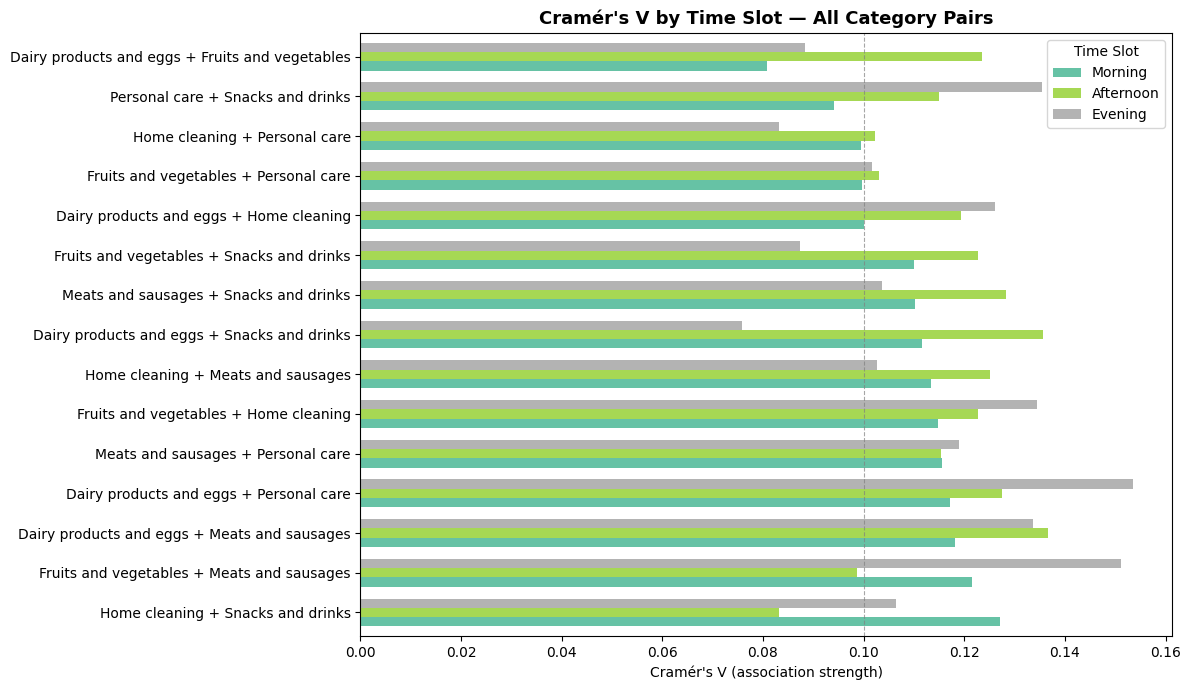

Time Slot                                        Morning  Afternoon  Evening
pair                                                                        
Home cleaning + Snacks and drinks                 0.1271     0.0831   0.1064
Fruits and vegetables + Meats and sausages        0.1216     0.0987   0.1512
Dairy products and eggs + Meats and sausages      0.1181     0.1367   0.1337
Dairy products and eggs + Personal care           0.1172     0.1275   0.1536
Meats and sausages + Personal care                0.1155     0.1154   0.1189
Fruits and vegetables + Home cleaning             0.1147     0.1228   0.1345
Home cleaning + Meats and sausages                0.1134     0.1251   0.1027
Dairy products and eggs + Snacks and drinks       0.1117     0.1357   0.0759
Meats and sausages + Snacks and drinks            0.1102     0.1283   0.1037
Fruits and vegetables + Snacks and drinks         0.1100     0.1228   0.0874
Dairy products and eggs + Home cleaning           0.1000     0.1193   0.1262

In [31]:
import matplotlib.pyplot as plt

# Pivot: pair vs time slot, values = Cramér's V
time_df["pair"] = time_df["Category A"] + " + " + time_df["Category B"]

pivot_v = time_df.pivot_table(
    index="pair", 
    columns="Time Slot", 
    values="Cramér's V"
)[["Morning", "Afternoon", "Evening"]]

# Sort by morning strength
pivot_v = pivot_v.sort_values("Morning", ascending=False)

# Save table
pivot_v.to_csv("../outputs/tables/cramers_v_by_timeslot.csv")

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
pivot_v.plot(kind="barh", ax=ax, colormap="Set2", width=0.7)
ax.set_title("Cramér's V by Time Slot — All Category Pairs", 
             fontsize=13, fontweight="bold")
ax.set_xlabel("Cramér's V (association strength)")
ax.set_ylabel("")
ax.legend(title="Time Slot")
ax.axvline(x=0.1, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.savefig("../outputs/figures/06_cramers_v_by_timeslot.png", dpi=150)
plt.show()

print(pivot_v.round(4))

## Summary of key findings

In [32]:
# Top 5 pairs with highest variation across time slots
pivot_v["variation"] = pivot_v.max(axis=1) - pivot_v.min(axis=1)
top_variable = pivot_v.sort_values("variation", ascending=False).head(5)

print("Top 5 pairs with highest association variation across time slots:")
print(top_variable.round(4))
print("\nInterpretation guide:")
print("  Cramér's V < 0.10 — weak association")
print("  Cramér's V 0.10-0.30 — moderate association")
print("  Cramér's V > 0.30 — strong association")

Top 5 pairs with highest association variation across time slots:
Time Slot                                        Morning  Afternoon  Evening  \
pair                                                                           
Dairy products and eggs + Snacks and drinks       0.1117     0.1357   0.0759   
Fruits and vegetables + Meats and sausages        0.1216     0.0987   0.1512   
Home cleaning + Snacks and drinks                 0.1271     0.0831   0.1064   
Dairy products and eggs + Fruits and vegetables   0.0807     0.1236   0.0884   
Personal care + Snacks and drinks                 0.0942     0.1150   0.1355   

Time Slot                                        variation  
pair                                                        
Dairy products and eggs + Snacks and drinks         0.0598  
Fruits and vegetables + Meats and sausages          0.0525  
Home cleaning + Snacks and drinks                   0.0440  
Dairy products and eggs + Fruits and vegetables     0.0429  
Persona